In [1]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

1. Use NumPy arrays from the score and attendance columns. Print both arrays and display:<br>

- Data type
- Number of dimensions
- Shape
- Total number of elements

In [3]:
print(f"Student scores: {student_scores}")
print(f"Data type: {student_scores.dtype}")
print(f"Dimensions: {student_scores.ndim}")
print(f"Shape: {student_scores.shape}")
print(f"Total number of elements: {student_scores.size}")

print("'''''''''''''''''''''''''''''''''")
print(f"Student attendance: {student_attendance}")
print(f"Data type: {student_attendance.dtype}")
print(f"Dimensions: {student_attendance.ndim}")
print(f"Shape: {student_attendance.shape}")
print(f"Total number of elements: {student_attendance.size}")

Student scores: [76 90 46 60 48 78 57 43 64 99 53 89 97 48 65 92 41 59 67 86 99 46 83 47
 86 74 53 56 75 89 79 43 41 45 93 81 43 93 68 57 65 83 73 49 75 53 70 87
 54 47]
Data type: int32
Dimensions: 1
Shape: (50,)
Total number of elements: 50
'''''''''''''''''''''''''''''''''
Student attendance: [73 82 99 80 75 77 83 85 84 88 74 60 84 66 68 83 60 67 83 70 76 67 94 94
 92 64 98 87 66 68 67 71 93 92 82 83 96 94 99 81 86 94 60 94 96 73 62 60
 64 85]
Data type: int32
Dimensions: 1
Shape: (50,)
Total number of elements: 50


2. Using NumPy functions on :<br>
- Find the maximum and minimum score
- Calculate the average score
- Calculate the average attendance<br><br>
Then, extract students who:
- Have a score greater than the average score<br>
Print: The filtered score array

In [13]:
print(f"Max score: {np.max(student_scores)}\nMin score: {np.min(student_scores)}")
avgScore = np.mean(student_scores)
avgAttendance = np.mean(student_attendance)
print(f"Average score: {avgScore}")
print(f"Average attendance: {avgAttendance}")

greater_score = student_scores > avgScore
filtered_score = student_scores[greater_score]
print(f"Score greater than the average score: {filtered_score}")

Max score: 99
Min score: 41
Average score: 67.3
Average attendance: 79.58
Score greater than the average score: [76 90 78 99 89 97 92 86 99 83 86 74 75 89 79 93 81 93 68 83 73 75 70 87]


3. Load the school_data.csv file into a Pandas DataFrame.<br>

- Display the first 3 rows
- Show dataset information using .info()
- Display summary statistics using .describe()<br>

Then filter the dataset to include only:<br>
- student_id, student_age, department, grade<br>
- Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.

In [ ]:
stdf = pd.read_csv("school_data.csv")
stdf.head(3)
print(stdf.info())
print("---------------------")
print(stdf.describe())
print("---------------------")

filtered_df = stdf.loc[:,['student_id','student_age','department','grade']]
print(filtered_df)

4. Using .loc:<br>

- Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
- Increase the score by 5% for all other departments
- Cap the score at 100 (no score should exceed 100 after the raise)<br><br>
Then print a DataFrame that includes:
- student_id, department, previous_score, new_score, score_increase

In [26]:
stdf.sample(5)

,student_id,student_age,score,attendance,department,grade
21,222,20,46,67,English,F
38,239,18,68,99,Mathematics,B
48,249,15,54,64,Science,C
46,247,21,70,62,Computer Science,B
23,224,18,47,94,Economics,F


In [29]:
stdf['previous_score'] = stdf['score'].copy()
stdf['score'] = stdf['score'].astype(float)
departments = (stdf['department'] == 'Computer Science') | (stdf['department'] == 'Mathematics')

stdf.loc[departments,'score'] = stdf.loc[departments,'score'] * 1.1
stdf.loc[~departments,'score'] = stdf.loc[~departments,'score'] * 1.05
stdf['score'] = stdf['score'].clip(upper=100)
stdf['new_score'] = stdf['score']

stdf['score_increase'] = stdf['new_score'] - stdf['previous_score']

new_st_df = stdf.loc[:,['student_id', 'department', 'previous_score', 'new_score', 'score_increase']]
new_st_df.sample(4)

,student_id,department,previous_score,new_score,score_increase
41,242,Economics,91.5075,96.082875,4.575375
7,208,Science,47.4075,49.777875,2.370375
0,201,Physics,83.7900,87.979500,4.189500
5,206,Arts,85.9950,90.294750,4.299750


Using Matplotlib, create a bar chart that shows the average score per department.<br>

- X-axis: Department names
- Y-axis: Average score
- Add a title: "Average Score by Department"
- Display the chart

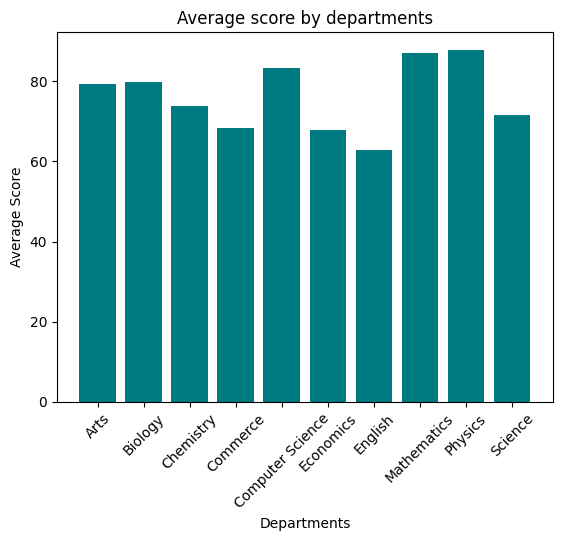

In [37]:
import matplotlib.pyplot as plt

score_group = stdf.groupby('department')['score'].mean()

plt.xlabel("Departments")
plt.ylabel("Average Score")
plt.title("Average score by departments")

plt.bar(score_group.index,score_group.values,color="#007A81")
plt.xticks(rotation=45)
plt.show()